In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest

In [2]:
strategies = [
    #('Momentum', momentum_strategy, 'mom', None, None),
    #('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    #("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    #("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    #("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [3]:
assets = ['AAPL']


AAPL


[*********************100%***********************]  1 of 1 completed


Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


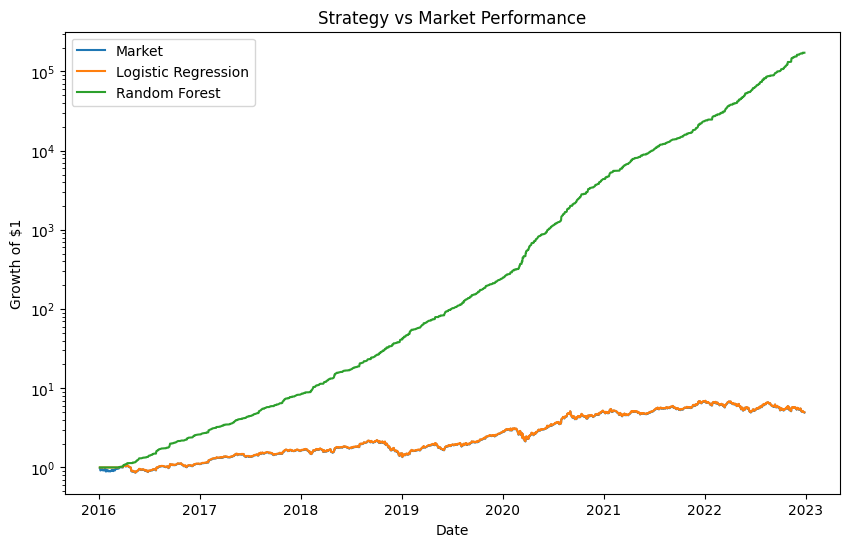

Testing Performance


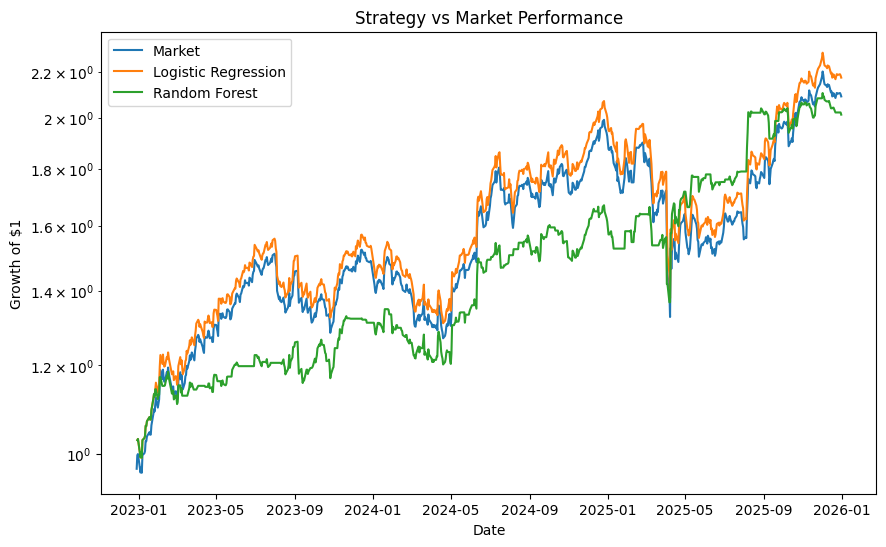


Training Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  0.905573    0.303760 -0.387297              NaN   
1  Logistic Regression  0.918925    0.298881 -0.387297         0.525867   
2        Random Forest  9.242371    0.189493  0.000000         0.984082   

   Signal Precision  Signal Recall  
0               NaN            NaN  
1          0.528655       0.969957  
2          1.000000       0.969957  

Testing Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  1.084576    0.257159 -0.334337              NaN   
1  Logistic Regression  1.138088    0.256622 -0.334337         0.549669   
2        Random Forest  1.221565    0.209031 -0.181449         0.537748   

   Signal Precision  Signal Recall  
0               NaN            NaN  
1          0.549072       1.000000  
2          0.569296       0.644928  


In [4]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    windows=range(2, 50, 2),
    logscale=True
)